# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska
## Hackathon - EDA

### Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import requests
import bs4 as bs
import yfinance as yf
import datetime
from scipy.stats import norm
from collections import Counter


from ipywidgets import interact, IntSlider, Checkbox
from functools import lru_cache
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Sigwatch Dataset

## Variables
#### Event identifiers
- **`uid_archive`** – Unique code identifying a campaign event (one or more firms may be targeted).  
- **`date`** – Date when the event was entered into the Sigwatch database (format: YYYY-MM-DD).

---

#### Company information
- **`company`** – Name of the targeted company (could be a parent, subsidiary, or brand).  
- **`company_type`** – Indicates whether the target is a *parent*, *subsidiary*, or *brand*.  
- **`company_parent`** – Name of parent company (if applicable).  
- **`company_parent_country`** – Country where the parent firm is legally headquartered or listed.  
- **`country_corp` / `country_corp_code`** – Country and code of the corporate headquarters.  
- **`isin_corporate_name_official`** – Official listed name of the company.  
- **`isin_corporate_name_cleaned`** – Same name, but with legal suffixes (Ltd, Inc, Plc, etc.) removed.  
- **`bloomberg_ticker`** – Bloomberg ticker symbol of the parent company (if listed).  
- **`isin_1` / `isin_2` / `isin_3`** – ISIN identifiers for the company or its parent, if available.

---

#### NGO and campaign characteristics
- **`sentiment`** – Tone of NGO communication toward the company:  
  - `-2` very negative, `-1` negative, `0` neutral, `+1` positive, `+2` very positive.  
- **`prominence`** – Visibility of the company in the NGO message:  
  - `+4` headline mention, `+3` first paragraph, `+2` elsewhere, `+1` in attached report.  
- **`partnership`** – Equals `1` if the company is working in partnership with the NGO.  

---

#### Issue and location variables
- **`issue_code_1–3` / `issue_name_1–3`** – Campaign topics, selected from 900+ predefined categories (e.g., *GMOs in food*, *Climate change*, *Herbicide impact*).  
- **`active_country_1–6`** – Country or countries where NGO action is taking place.  
- **`target_country_1–6`** – Country or countries targeted by the NGO (may overlap with active countries).

---

#### NGO information
- **`ngo_code_1–5` / `ngo_name_1–5`** – Code and name(s) of the NGO(s) involved in the event.  
- **`ngo_country_code` / `ngo_country`** – Headquarters country of the NGO or its branch.  
- **`ngo_power`** – Scale of NGO influence, from *local* (lowest) to *global* (highest).

---

#### Industry classification
- **`corp_industry_sector_code_1–3`** – Codes for the firm’s industrial activities (Sigwatch-specific, not standard NAICS/SIC).  
- **`corp_industry_sector_1–3`** – Text description of those sectors.  
- **`industry_sector_code_1–4`** – Codes describing the sector affected by the specific campaign.  
- **`industry_sector_1–4`** – Text description of those campaign-related sectors.

---

#### Sources and text
- **`report`** – Text summary of the campaign event, written by Sigwatch.  
- **`link_1–5`** – URLs linking to original NGO statements or reports.


In [2]:
years = range(2010, 2019)
sigwatch_data = {}

for year in years:
    df = pd.read_stata(f"sigwatch_data/{year}_data_sigwatch.dta")
    sigwatch_data[year] = df


In [3]:
years = range(2010, 2019)

for year in years:
    print(year, "dimension:", sigwatch_data[year].shape)

2010 dimension: (3439, 94)
2011 dimension: (6030, 94)
2012 dimension: (7366, 94)
2013 dimension: (8488, 94)
2014 dimension: (8761, 94)
2015 dimension: (8547, 94)
2016 dimension: (8582, 94)
2017 dimension: (9307, 94)
2018 dimension: (12574, 94)


In [4]:
sigwatch_data[2010].columns

Index(['uid_archive', 'date', 'company_code', 'company', 'company_type',
       'company_parent_code', 'company_parent', 'company_parent_country',
       'sentiment', 'prominence', 'partnership', 'issue_code1', 'issue_name1',
       'issue_code2', 'issue_name2', 'issue_code3', 'issue_name3',
       'active_country_code1', 'active_country1', 'active_country_code2',
       'active_country2', 'active_country_code3', 'active_country3',
       'active_country_code4', 'active_country4', 'active_country_code5',
       'active_country5', 'active_country_code6', 'active_country6',
       'target_country_code1', 'target_country1', 'target_country_code2',
       'target_country2', 'target_country_code3', 'target_country3',
       'target_country_code4', 'target_country4', 'target_country_code5',
       'target_country5', 'target_country_code6', 'target_country6',
       'ngo_code1', 'ngo_name1', 'ngo_power1', 'ngo_country_code1',
       'ngo_country1', 'ngo_code2', 'ngo_name2', 'ngo_power2',
    

In [5]:
sigwatch_data[2010].head(5)

,uid_archive,date,company_code,company,company_type,company_parent_code,company_parent,company_parent_country,sentiment,prominence,partnership,issue_code1,issue_name1,issue_code2,issue_name2,issue_code3,issue_name3,active_country_code1,active_country1,active_country_code2,active_country2,active_country_code3,active_country3,active_country_code4,active_country4,active_country_code5,active_country5,active_country_code6,active_country6,target_country_code1,target_country1,target_country_code2,target_country2,target_country_code3,target_country3,target_country_code4,target_country4,target_country_code5,target_country5,target_country_code6,target_country6,ngo_code1,ngo_name1,ngo_power1,ngo_country_code1,ngo_country1,ngo_code2,ngo_name2,ngo_power2,ngo_country_code2,ngo_country2,ngo_code3,ngo_name3,ngo_power3,ngo_country_code3,ngo_country3,ngo_code4,ngo_name4,ngo_power4,ngo_country_code4,ngo_country4,ngo_code5,ngo_name5,ngo_power5,ngo_country_code5,ngo_country5,country_code_corp,country_corp,corp_industry_sector_code1,corp_industry_sector1,corp_industry_sector_code2,corp_industry_sector2,corp_industry_sector_code3,corp_industry_sector3,isin_corporate_name_official,isin_corporate_name_cleaned,bloomberg_ticker,isin_1,isin_2,isin_3,industry_sector_code1,industry_sector1,industry_sector_code2,industry_sector2,industry_sector_code3,industry_sector3,industry_sector_code4,industry_sector4,report,link1,link2,link3,link4,link5
0,36273,2010-10-01,67,Tesoro,Parent,67,Tesoro,US,-1,2,0,3443,Climate change - intl/govt action on GHG emiss...,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,275,Consumers Union USA,1.5,840,US,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,840,US,1327,Oil,NaN,,NaN,,Tesoro Corp,Tesoro,TSO,US8816091016,,,1315.0,Energy,1325.0,Power generation,1332.0,Renewable energy,NaN,NaN,"In the U.S., Consumers Union added its influen...",http://www.consumersunion.org/pub/core_other_i...,,,,NaN
1,36273,2010-10-01,103,Valero Energy Corporation,Parent,103,Valero Energy Corporation,US,-1,2,0,3443,Climate change - intl/govt action on GHG emiss...,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,275,Consumers Union USA,1.5,840,US,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,840,US,1286,Chemicals,1315.0,Energy,1327.0,Oil,Valero Energy Corp,Valero Energy,VLO,US91913Y1001,,,1315.0,Energy,1325.0,Power generation,1332.0,Renewable energy,NaN,NaN,"In the U.S., Consumers Union added its influen...",http://www.consumersunion.org/pub/core_other_i...,,,,NaN
2,36247,2010-01-06,4,Pfizer,Parent,4,Pfizer,US,-1,2,0,3375,Drug safety,NaN,,NaN,,392,Japan,NaN,,NaN,,NaN,,NaN,,NaN,,392,Japan,NaN,,NaN,,NaN,,NaN,,NaN,,628,Medwatcher Japan,1.0,392,Japan,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,840,US,1340,Pharmaceuticals,NaN,,NaN,,Pfizer Inc,Pfizer,PFE,US7170811035,,,1340.0,Pharmaceuticals,NaN,,NaN,,NaN,NaN,"<p>In Japan, Medwatcher/Yakugai demanded Pfize...",http://www.yakugai.gr.jp/en/topics/topic.php?i...,,,,NaN
3,35283,2010-12-23,277,C&A,Parent,277,C&A,Germany,0,2,0,3380,Fashion - supply chain responsibility,3974.0,Sandblasting denim,NaN,,756,Switzerland,NaN,,NaN,,NaN,,NaN,,NaN,,756,Switzerland,NaN,,NaN,,NaN,,NaN,,NaN,,130,Berne Declaration EvB,1.0,756,Switzerland,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,276,Germany,1352,Fashion,1322.0,Retail,1351.0,Textiles,,,,,,,1351.0,Textiles,1352.0,Fashion,NaN,,NaN,NaN,", while Lee, Wrangler and Benetton have agreed...",http://www.evb.ch/p25018978.html,,,,NaN
4,35283,2010-12-23,282,Levi Strauss & Co,Parent,282,Levi Strauss & Co,US,0,2,0,3380,Fashion - supply chain responsibility,3974.0,Sandblasting denim,NaN,,756,Switzerland,NaN,,NaN,,NaN,,NaN,,NaN,,756,Switzerland,NaN,,NaN,,NaN,,NaN,,NaN,,130,Berne Declaration EvB,1.0,756,Switzerland,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,840,US,1352,Fashion,1351.0,Textiles,NaN,,,,,,,,1351.0,Textiles,1352.0,Fashion,NaN,,NaN,NaN,", while Lee, Wrangler and Benetton have agree

## Dataset Exploration

In [6]:
# Combine all years into one DataFrame
combined = pd.concat(sigwatch_data.values(), ignore_index=True)
print("Combined shape:", combined.shape)

display(combined.head())

Combined shape: (73094, 94)


,uid_archive,date,company_code,company,company_type,company_parent_code,company_parent,company_parent_country,sentiment,prominence,partnership,issue_code1,issue_name1,issue_code2,issue_name2,issue_code3,issue_name3,active_country_code1,active_country1,active_country_code2,active_country2,active_country_code3,active_country3,active_country_code4,active_country4,active_country_code5,active_country5,active_country_code6,active_country6,target_country_code1,target_country1,target_country_code2,target_country2,target_country_code3,target_country3,target_country_code4,target_country4,target_country_code5,target_country5,target_country_code6,target_country6,ngo_code1,ngo_name1,ngo_power1,ngo_country_code1,ngo_country1,ngo_code2,ngo_name2,ngo_power2,ngo_country_code2,ngo_country2,ngo_code3,ngo_name3,ngo_power3,ngo_country_code3,ngo_country3,ngo_code4,ngo_name4,ngo_power4,ngo_country_code4,ngo_country4,ngo_code5,ngo_name5,ngo_power5,ngo_country_code5,ngo_country5,country_code_corp,country_corp,corp_industry_sector_code1,corp_industry_sector1,corp_industry_sector_code2,corp_industry_sector2,corp_industry_sector_code3,corp_industry_sector3,isin_corporate_name_official,isin_corporate_name_cleaned,bloomberg_ticker,isin_1,isin_2,isin_3,industry_sector_code1,industry_sector1,industry_sector_code2,industry_sector2,industry_sector_code3,industry_sector3,industry_sector_code4,industry_sector4,report,link1,link2,link3,link4,link5
0,36273,2010-10-01,67,Tesoro,Parent,67,Tesoro,US,-1,2,0,3443,Climate change - intl/govt action on GHG emiss...,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,275,Consumers Union USA,1.5,840,US,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,840,US,1327.0,Oil,NaN,,NaN,,Tesoro Corp,Tesoro,TSO,US8816091016,,,1315.0,Energy,1325.0,Power generation,1332.0,Renewable energy,NaN,NaN,"In the U.S., Consumers Union added its influen...",http://www.consumersunion.org/pub/core_other_i...,,,,NaN
1,36273,2010-10-01,103,Valero Energy Corporation,Parent,103,Valero Energy Corporation,US,-1,2,0,3443,Climate change - intl/govt action on GHG emiss...,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,840,US,NaN,,NaN,,NaN,,NaN,,NaN,,275,Consumers Union USA,1.5,840,US,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,840,US,1286.0,Chemicals,1315.0,Energy,1327.0,Oil,Valero Energy Corp,Valero Energy,VLO,US91913Y1001,,,1315.0,Energy,1325.0,Power generation,1332.0,Renewable energy,NaN,NaN,"In the U.S., Consumers Union added its influen...",http://www.consumersunion.org/pub/core_other_i...,,,,NaN
2,36247,2010-01-06,4,Pfizer,Parent,4,Pfizer,US,-1,2,0,3375,Drug safety,NaN,,NaN,,392,Japan,NaN,,NaN,,NaN,,NaN,,NaN,,392,Japan,NaN,,NaN,,NaN,,NaN,,NaN,,628,Medwatcher Japan,1.0,392,Japan,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,840,US,1340.0,Pharmaceuticals,NaN,,NaN,,Pfizer Inc,Pfizer,PFE,US7170811035,,,1340.0,Pharmaceuticals,NaN,,NaN,,NaN,NaN,"<p>In Japan, Medwatcher/Yakugai demanded Pfize...",http://www.yakugai.gr.jp/en/topics/topic.php?i...,,,,NaN
3,35283,2010-12-23,277,C&A,Parent,277,C&A,Germany,0,2,0,3380,Fashion - supply chain responsibility,3974.0,Sandblasting denim,NaN,,756,Switzerland,NaN,,NaN,,NaN,,NaN,,NaN,,756,Switzerland,NaN,,NaN,,NaN,,NaN,,NaN,,130,Berne Declaration EvB,1.0,756,Switzerland,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,276,Germany,1352.0,Fashion,1322.0,Retail,1351.0,Textiles,,,,,,,1351.0,Textiles,1352.0,Fashion,NaN,,NaN,NaN,", while Lee, Wrangler and Benetton have agreed...",http://www.evb.ch/p25018978.html,,,,NaN
4,35283,2010-12-23,282,Levi Strauss & Co,Parent,282,Levi Strauss & Co,US,0,2,0,3380,Fashion - supply chain responsibility,3974.0,Sandblasting denim,NaN,,756,Switzerland,NaN,,NaN,,NaN,,NaN,,NaN,,756,Switzerland,NaN,,NaN,,NaN,,NaN,,NaN,,130,Berne Declaration EvB,1.0,756,Switzerland,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,NaN,,NaN,NaN,,840,US,1352.0,Fashion,1351.0,Textiles,NaN,,,,,,,,1351.0,Textiles,1352.0,Fashion,NaN,,NaN,NaN,", while Lee, Wrangler and Benetton 

### Nulls

In [7]:
# Nulls table
nulls = combined.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(combined) * 100).round(2)
null_df = pd.DataFrame({"missing_count": nulls, "missing_pct": nulls_pct})

# Show top 30 missing columns
display(null_df.head(30))

,missing_count,missing_pct
link5,73094,100.00
industry_sector4,73094,100.00
industry_sector_code4,73094,100.00
active_country_code6,73083,99.98
active_country_code5,73028,99.91
active_country_code4,72775,99.56
target_country_code6,72252,98.85
active_country_code3,71972,98.46
ngo_code5,71902,98.37
ngo_power5,71902,98.37


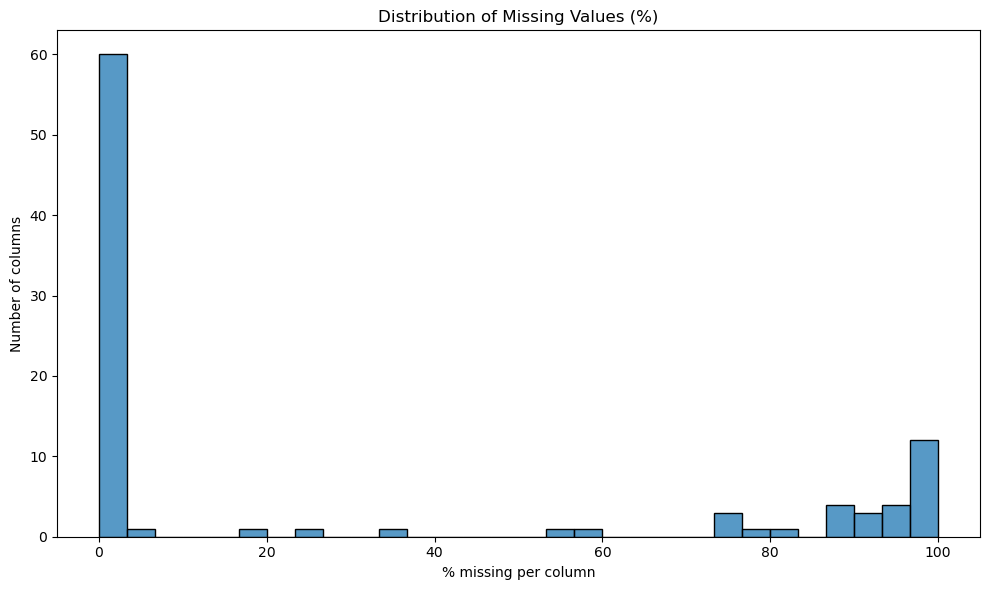

In [8]:
# Histogram of % missing across columns
plt.figure(figsize=(10,6))
sns.histplot(null_df["missing_pct"], bins=30)
plt.title("Distribution of Missing Values (%)")
plt.xlabel("% missing per column")
plt.ylabel("Number of columns")
plt.tight_layout()
plt.show()

### By country

In [9]:
# Unique issues per Active Country
country_issue_counts = (
    combined
      .assign(active_country1=combined["active_country1"].fillna("Unknown"))
      .groupby("active_country1")["issue_name1"]
      .nunique()
      .sort_values(ascending=False)
)

# Top-20 table
display(country_issue_counts.head(20).to_frame(name="unique_issues_per_country"))


,unique_issues_per_country
active_country1,
US,410
USA,369
UK,351
Germany,294
Netherlands,231
France,194
Spain,191
Denmark,165
Norway,161


/var/folders/z_/_fwllf5j5n570_9sjbckq9mc0000gn/T/ipykernel_24954/2582197269.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


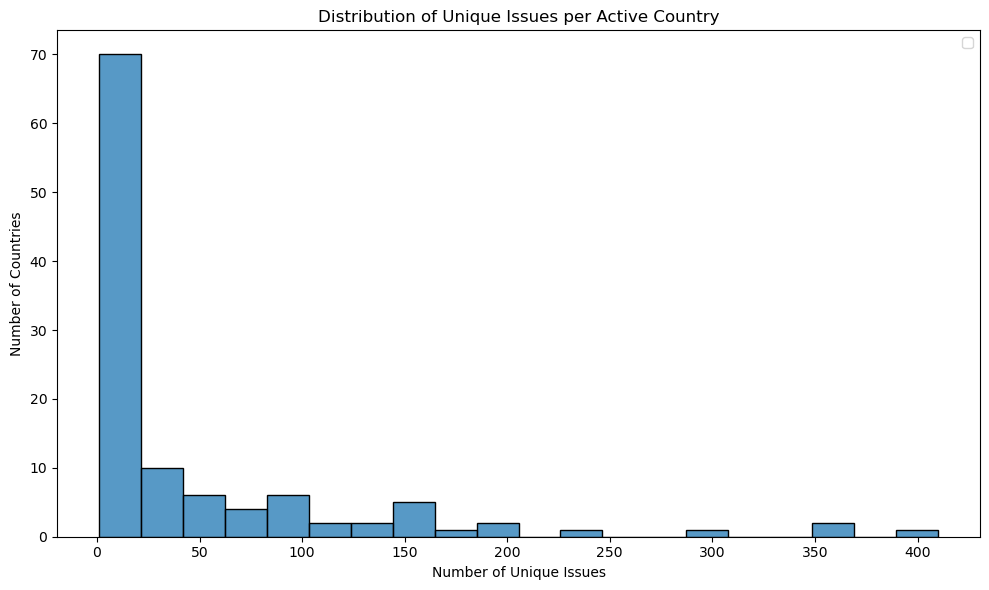

In [10]:
plt.figure(figsize=(10,6))
sns.histplot(country_issue_counts, bins=20, kde=False)
plt.title("Distribution of Unique Issues per Active Country")
plt.xlabel("Number of Unique Issues")
plt.ylabel("Number of Countries")
plt.legend()
plt.tight_layout()
plt.show()

### Domenstic vs. foreign

country corp vs ngo country 1

In [11]:
# Compare NGO country vs company country (home vs foreign)
combined["home_target"] = np.where(
    combined["ngo_country1"] == combined["country_corp"],
    "Domestic Target",
    "Foreign Target"
)
home_foreign = combined["home_target"].value_counts(normalize=True) * 100
display(home_foreign.to_frame(name="% of campaigns"))


,% of campaigns
home_target,
Domestic Target,56.758421
Foreign Target,43.241579


/var/folders/z_/_fwllf5j5n570_9sjbckq9mc0000gn/T/ipykernel_24954/1045232896.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=home_foreign.index, y=home_foreign.values, palette="Set2")


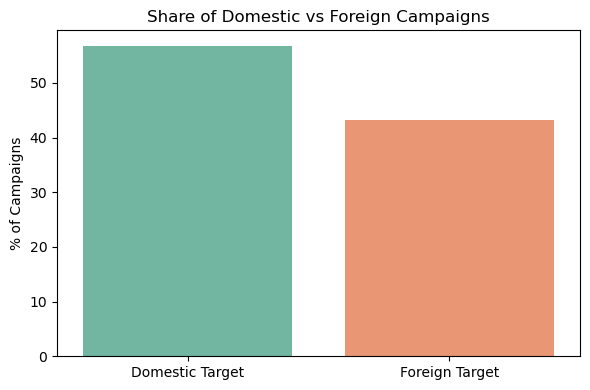

In [12]:
plt.figure(figsize=(6,4))
sns.barplot(x=home_foreign.index, y=home_foreign.values, palette="Set2")
plt.title("Share of Domestic vs Foreign Campaigns")
plt.ylabel("% of Campaigns")
plt.xlabel("")
plt.tight_layout()
plt.show()


In [13]:
# Unique issues per NGO
ngo_issue_counts = (
    combined
      .assign(ngo_name1=combined["ngo_name1"].fillna("Unknown"))
      .groupby("ngo_name1")["issue_name1"]
      .nunique()
      .sort_values(ascending=False)
)

# Top-20 table
display(ngo_issue_counts.head(20).to_frame(name="unique_issues_per_ngo"))

,unique_issues_per_ngo
ngo_name1,
Friends of the Earth U.S. / FoE U.S.,79
Greenpeace USA,69
Sierra Club U.S.A.,68
Center for Biological Diversity CBD,68
Greenpeace Germany,65
Greenpeace UK,62
Natural Resources Defense Council NRDC,61
Greenpeace Spain,56
Food & Water Watch FWW,55


/var/folders/z_/_fwllf5j5n570_9sjbckq9mc0000gn/T/ipykernel_24954/4132975838.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


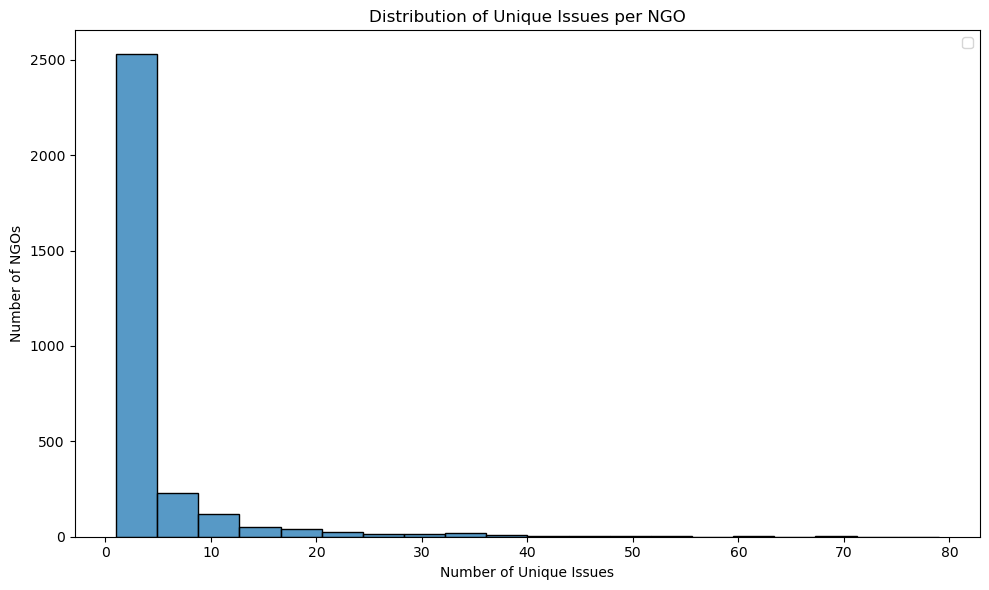

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(ngo_issue_counts, bins=20, kde=False)
plt.title("Distribution of Unique Issues per NGO")
plt.xlabel("Number of Unique Issues")
plt.ylabel("Number of NGOs")
plt.legend()
plt.tight_layout()
plt.show()

### By Year

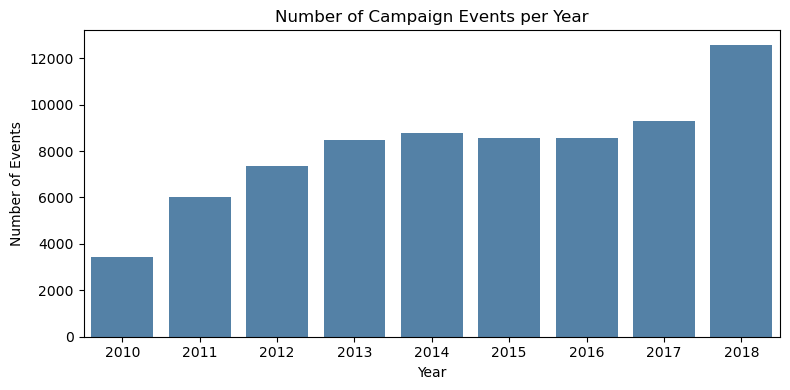

In [15]:
# Campaign frequency by year
combined["year"] = pd.to_datetime(combined["date"], errors="coerce").dt.year
campaigns_by_year = combined["year"].value_counts().sort_index()

plt.figure(figsize=(8,4))
sns.barplot(x=campaigns_by_year.index, y=campaigns_by_year.values, color="steelblue")
plt.title("Number of Campaign Events per Year")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.show()


### By sentiment

/var/folders/z_/_fwllf5j5n570_9sjbckq9mc0000gn/T/ipykernel_24954/3876727376.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index.astype(str), y=sentiment_counts.values, palette="coolwarm")


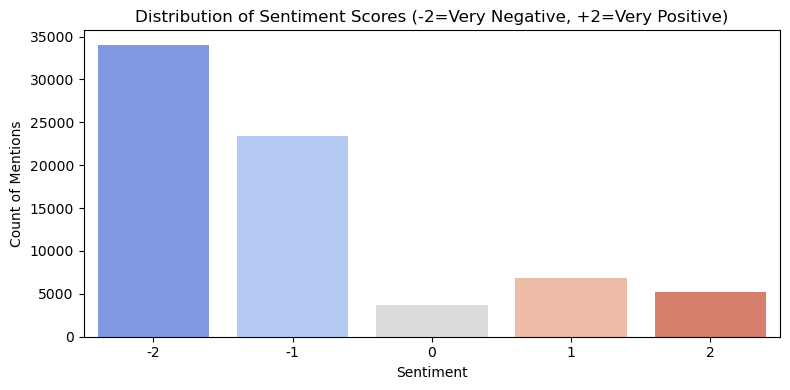

In [16]:
# Distribution of sentiment scores
sentiment_counts = combined["sentiment"].value_counts().sort_index()

plt.figure(figsize=(8,4))
sns.barplot(x=sentiment_counts.index.astype(str), y=sentiment_counts.values, palette="coolwarm")
plt.title("Distribution of Sentiment Scores (-2=Very Negative, +2=Very Positive)")
plt.xlabel("Sentiment")
plt.ylabel("Count of Mentions")
plt.tight_layout()
plt.show()


In [17]:
# Top targeted parent companies
top_companies = combined["company_parent"].value_counts().head(20)
display(top_companies.to_frame(name="num_events"))

,num_events
company_parent,
Monsanto,1025
Shell (Royal Dutch Shell),821
TransCanada,704
Nestle,702
Walmart,594
BP,590
Unilever,572
ExxonMobil,542
Coca-Cola Company,511


### Sectors

In [18]:
# Top sectors targeted
top_sectors = combined["corp_industry_sector1"].value_counts().head(20)
display(top_sectors.to_frame(name="num_events"))

,num_events
corp_industry_sector1,
Food & Non-alcoholic Beverages,11325
Finance,8347
Retail,5670
Energy,4078
"Electronics, Telecoms & Digital",3794
Fashion,3734
Oil,3544
Oil & Gas,2269
Agriculture,2201


In [19]:
# Number of campaigns by NGO country
ngo_country_activity = combined["ngo_country1"].value_counts().sort_values(ascending=False)

display(ngo_country_activity.head(20).to_frame(name="num_campaigns"))

,num_campaigns
ngo_country1,
US,13205
USA,10151
UK,9304
Netherlands,4522
Germany,4506
France,2246
Spain,2226
Canada,1976
Denmark,1847


### Issues appearing together often

In [20]:
from itertools import combinations

# Select all issue name columns (handles issue_name1..issue_name5 if present)
issue_cols = [c for c in combined.columns if c.startswith("issue_name")]

# Collect all issue pairs across events
pair_counter = Counter()

for _, row in combined[issue_cols].dropna(how="all").iterrows():
    # get all unique non-null issue names for this row
    issues = list({str(i).strip() for i in row if pd.notna(i) and str(i).strip()})
    # count all unordered pairs of co-occurring issues
    for a, b in combinations(sorted(issues), 2):
        pair_counter[(a, b)] += 1

# Convert to DataFrame
issue_pairs_all = (
    pd.DataFrame(pair_counter.items(), columns=["pair", "count"])
      .assign(issue1=lambda x: x["pair"].str[0],
              issue2=lambda x: x["pair"].str[1])
      .drop(columns="pair")
      .sort_values("count", ascending=False)
      .reset_index(drop=True)
)

# Display top 20 co-occurring issue pairs
display(issue_pairs_all.head(20))


,count,issue1,issue2
0,884,Fashion - supply chain responsibility,Labor rights in general
1,624,Oil and gas pipelines,Oilsands and oilshale
2,544,Biotech - regulation and labelling,GMOs in food
3,543,Fair pay and living wage,Fashion - supply chain responsibility
4,508,Dams - impact on indigenous people,Hydro - large dams
5,501,"Coal, oil & gas and climate change","Financial institutions & carbon, divestment"
6,497,"Palm oil in food, toiletries & detergents","Palm oil plantations displacing rainforest, peat"
7,413,"Financial institutions & carbon, divestment","Oil, gas, coal & climate change"
8,336,"Financial institutions & carbon, divestment",Fossil fuels & climate change
9,332,Child obesity and nutrition,Food marketing to children


### Sentiment by sector

In [21]:
sentiment_by_sector = combined.groupby("corp_industry_sector1")["sentiment"].mean().sort_values(ascending=False)

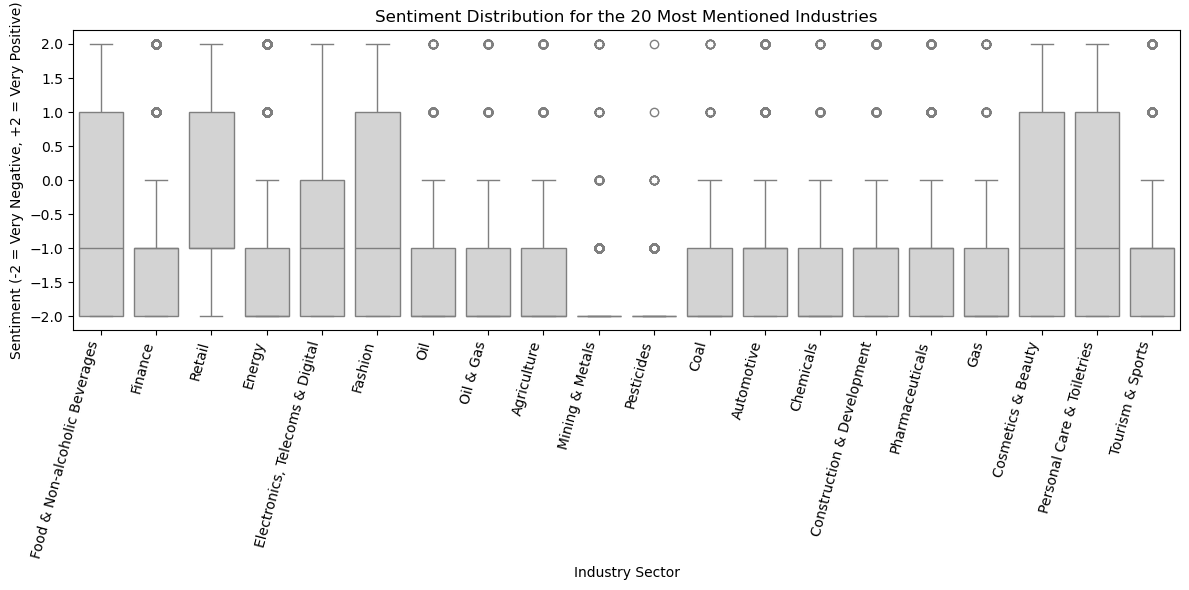

In [22]:
# Drop rows where industry is missing
valid_industries = combined.dropna(subset=["corp_industry_sector1"])

# Find 20 most mentioned industries (by number of campaign events)
top20_industries = (
    valid_industries["corp_industry_sector1"]
    .value_counts()
    .head(20)
    .index
)

# Subset the data
subset = valid_industries[valid_industries["corp_industry_sector1"].isin(top20_industries)]

# --- Boxplot (no color palette) ---
plt.figure(figsize=(12,6))
sns.boxplot(
    data=subset,
    x="corp_industry_sector1",
    y="sentiment",
    order=top20_industries,
    color="lightgray"
)
plt.title("Sentiment Distribution for the 20 Most Mentioned Industries")
plt.xlabel("Industry Sector")
plt.ylabel("Sentiment (-2 = Very Negative, +2 = Very Positive)")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

In [23]:
# Clean industry field: convert blanks to NaN
combined["corp_industry_sector1"] = (
    combined["corp_industry_sector1"]
    .replace("", np.nan)
    .replace(" ", np.nan)
)

# Drop missing industries
valid_industries = combined.dropna(subset=["corp_industry_sector1"])

# --- Compute mean sentiment & count per industry ---
mean_stats = (
    valid_industries.groupby("corp_industry_sector1")["sentiment"]
    .agg(mean_sentiment="mean", count_records="count")
    .query("count_records >= 100")              # keep industries with enough data
    .sort_values("mean_sentiment", ascending=False)
)

# --- Display top/bottom 3 ---
top3_mean = mean_stats.head(3)
bottom3_mean = mean_stats.tail(3)

print("Top 3 Industries by Mean Sentiment (≥100 records):")
display(top3_mean)

print("\nBottom 3 Industries by Mean Sentiment (≥100 records):")
display(bottom3_mean)


Top 3 Industries by Mean Sentiment (≥100 records):


,mean_sentiment,count_records
corp_industry_sector1,,
Sportswear,-0.197452,157
Fashion,-0.301285,3734
Quick Service Restaurants,-0.339683,315



Bottom 3 Industries by Mean Sentiment (≥100 records):


,mean_sentiment,count_records
corp_industry_sector1,,
Pesticides,-1.788228,1563
Hydro and large dams,-1.806931,404
Hydro power,-1.833333,216


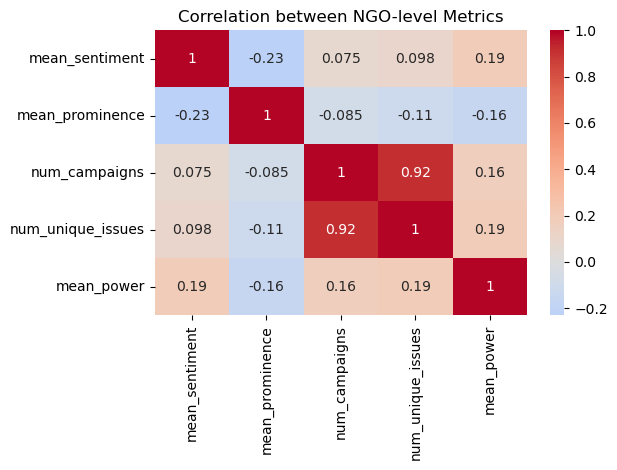

In [24]:
ngo_summary = (
    combined.groupby("ngo_name1")
    .agg(
        mean_sentiment=("sentiment", "mean"),
        mean_prominence=("prominence", "mean"),
        num_campaigns=("uid_archive", "nunique"),
        num_unique_issues=("issue_name1", "nunique"),
        mean_power=("ngo_power1", "mean")
    )
    .corr()
)

sns.heatmap(ngo_summary, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation between NGO-level Metrics")
plt.tight_layout()
plt.show()

## Refining dataset to only banks/finance

In [25]:
# Keep only rows where industry is exactly "Finance"
finance_df = combined[combined["corp_industry_sector1"] == "Finance"].copy()

print("Finance-only dataset shape:", finance_df.shape)
print(f"{finance_df.shape[0] / combined.shape[0] * 100:.2f}% of full dataset")

Finance-only dataset shape: (8347, 96)
11.42% of full dataset


### Most targeted financial institutions

In [26]:
top_finance_companies = finance_df["company_parent"].value_counts().head(15)
display(top_finance_companies.to_frame(name="num_events"))

,num_events
company_parent,
World Bank,298
HSBC,247
BNP Paribas,228
Deutsche Bank,207
JP Morgan Chase,186
Bank of America,179
Barclays Bank,172
ING,169
RBS Group,169


### Issues by sentiment

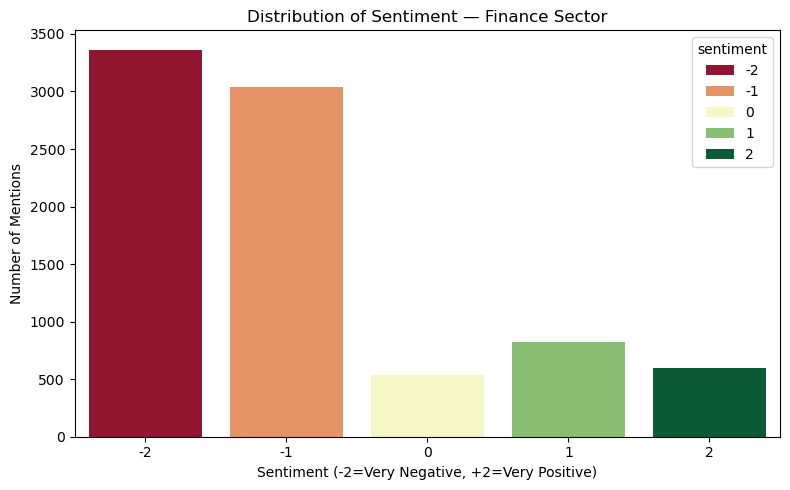

Average Sentiment (Finance Sector): -0.93


In [27]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=finance_df,
    x="sentiment",
    hue="sentiment",
    palette="RdYlGn")
plt.title("Distribution of Sentiment — Finance Sector")
plt.xlabel("Sentiment (-2=Very Negative, +2=Very Positive)")
plt.ylabel("Number of Mentions")
plt.tight_layout()
plt.show()

print("Average Sentiment (Finance Sector):", finance_df["sentiment"].mean().round(2))

### Countries by issues with percentage of total

In [28]:
# Top 15 active countries by event count
active_countries = (
    finance_df["active_country1"]
    .value_counts()
    .head(15)
    .to_frame(name="num_events")
)

# Add percentage of total
total_events = finance_df["active_country1"].notna().sum()
active_countries["percent_of_total"] = (
    active_countries["num_events"] / total_events * 100
).round(2)

display(active_countries)

,num_events,percent_of_total
active_country1,,
UK,1278,15.31
USA,1069,12.81
US,999,11.97
Netherlands,785,9.40
France,475,5.69
Germany,450,5.39
Spain,324,3.88
Australia,280,3.35
Belgium,276,3.31


### Over time

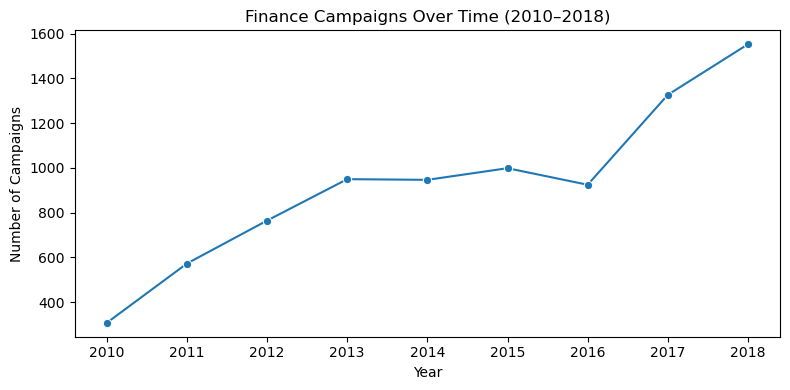

In [29]:
finance_df["year"] = pd.to_datetime(finance_df["date"], errors="coerce").dt.year
finance_trend = finance_df["year"].value_counts().sort_index()

plt.figure(figsize=(8,4))
sns.lineplot(x=finance_trend.index, y=finance_trend.values, marker="o")
plt.title("Finance Campaigns Over Time (2010–2018)")
plt.xlabel("Year")
plt.ylabel("Number of Campaigns")
plt.tight_layout()
plt.show()


### Top issues

In [30]:
finance_issues = (
    pd.concat([
        finance_df["issue_name1"],
        finance_df["issue_name2"],
        finance_df["issue_name3"]
    ])
    .value_counts()
    .head(20)
)
display(finance_issues.to_frame(name="count"))

,count
,6457
"Financial institutions & carbon, divestment",2146
CSR/ESG standards for financial institutions,1109
Financial institutions & consumer protection,794
Financial institutions & customer service,483
Regulation of financial institutions,454
Ethical investing/SRI,423
Financial institutions funding arms industry,415
"Tax havens, avoidance & financial transparency",405
Oil and gas pipelines,365


### See if any NGOs target any specific companies

In [31]:
# pick NGO columns
ngo_cols = ["ngo_name1", "ngo_name2", "ngo_name3", "ngo_name4", "ngo_name5"]

# reshape to long format
ngo_company_pairs = (
    finance_df.melt(
        id_vars="company_parent",
        value_vars=ngo_cols,
        value_name="ngo_name"
    )
    .dropna(subset=["ngo_name", "company_parent"])
)

# count pairs
pair_counts = (
    ngo_company_pairs
    .groupby(["ngo_name", "company_parent"])
    .size()
    .reset_index(name="num_campaigns")
    .sort_values("num_campaigns", ascending=False)
)

display(pair_counts.head(20))

,ngo_name,company_parent,num_campaigns
989,,World Bank,995
465,,HSBC,907
106,,BNP Paribas,738
354,,Deutsche Bank,697
186,,Barclays Bank,624
759,,RBS Group,621
524,,JP Morgan Chase,621
153,,Bank of America,608
489,,ING,592
299,,Citigroup,561
